<a href="https://colab.research.google.com/github/saharacodie/genai_chatbot/blob/main/GenAI_ChatBot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Clean Garbage Collector**


In [ ]:
#del llm
import torch, gc
gc.collect()
torch.cuda.empty_cache()


#Hugging Face

In [ ]:
%%capture
!pip install -q transformers torch accelerate


In [ ]:
%%capture
!pip install streamlit

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

# Create a pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False,
)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

#Introduction to LLM

In [ ]:
prompt = "Explain overfitting in machine learning."

response_output_wrapper = pipe(
    prompt,
    max_new_tokens=150,
    max_length=None,
    pad_token_id=pipe.tokenizer.eos_token_id
)
print(response_output_wrapper[0]['generated_text'])

🔷 Standard Structured Prompt Template

In [ ]:
prompt = f"""
### ROLE:
You are an expert Data Science Trainer.

### TASK:
Explain the concept of NumPy Broadcasting.

### CONTEXT:
The audience is beginners learning Python for Machine Learning.

### INSTRUCTIONS:
- Use simple language
- Provide real-world analogy
- Include code example

### OUTPUT FORMAT:
1. Definition
2. Example
3. Code
4. Summary
"""
print(pipe(prompt)[0]['generated_text'])

In [ ]:
prompt = f"""
<System>
You are a senior AI/ML instructor with 10+ years of experience.

<User>
Explain NumPy Broadcasting.

<Context>
Audience: Beginners in Data Science
Goal: Understand concept + apply in coding

<Constraints>
- Avoid complex math
- Keep explanation intuitive
- Include visuals explanation (textual)

<Output Format>
- Concept Explanation
- Step-by-step Example
- Python Code
- Real-world Use Case
"""

 Industry-Level Structured Prompt (Advanced)

In [ ]:
prompt = f"""
<System>
You are a senior AI/ML instructor with 10+ years of experience.

<User>
Explain NumPy Broadcasting.

<Context>
Audience: Beginners in Data Science
Goal: Understand concept + apply in coding

<Constraints>
- Avoid complex math
- Keep explanation intuitive
- Include visuals explanation (textual)

<Output Format>
- Concept Explanation
- Step-by-step Example
- Python Code
- Real-world Use Case
"""


Few-Shot Prompt Structure (Production Style)

Real-Time Use Case: Customer Support Auto-Response (AI Agent)

In [ ]:
prompt = f"""
You are a professional customer support assistant.

Respond to user queries in a polite, helpful, and concise manner.

### Examples:

User: My internet is not working since morning.
Assistant: I'm sorry for the inconvenience. Please try restarting your router. If the issue persists, I will raise a support ticket for you.

User: I was charged twice for my subscription.
Assistant: I apologize for the inconvenience. Please share your transaction details, and I will help you with the refund process immediately.

User: I want to cancel my plan.
Assistant: Sure, I can help you with that. Please confirm your account details so I can proceed with the cancellation.

### Now respond to the following:

User: My Firestick is not working and I already returned it but still getting billed.
Assistant:
"""

In [ ]:
#user_query = "Payment deducted but service not activated"
user_query=input("User:`")
prompt = f"""
You are a customer support assistant.

Follow the tone and structure of examples.

### Examples:
User: Unable to login
Assistant: Please try resetting your password. Let me know if you need further help.

User: Payment failed but money deducted
Assistant: Sorry for the inconvenience. Please share transaction ID so we can verify and assist you.

### Query:
User: {user_query}
Assistant:
"""
print(pipe(prompt)[0]['generated_text'])

#Depoloyed Using Streamlit

#**CHATBOT**

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# Load model and tokenizer (moved from a previous cell for self-containment)
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

llm = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    pad_token_id=tokenizer.eos_token_id,
    max_new_tokens=150   # ✅ define here
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
print("Chatbot initialized. Type 'quit' to exit.")

from transformers import logging
logging.set_verbosity_error()

messages = [
    {"role": "system", "content": "You are a helpful assistant."}
]

while True:
    user_input = input("You: ")
    if user_input.lower() == 'quit':
        break

    messages.append({"role": "user", "content": user_input})

    response_output_wrapper = llm(
        messages,
        max_new_tokens=150,
        pad_token_id=llm.tokenizer.eos_token_id
    )

    full_conversation_list = response_output_wrapper[0]['generated_text']
    assistant_new_text = full_conversation_list[-1]['content']

    print(f"Assistant: {assistant_new_text}")

    messages = full_conversation_list[-10:]  # limit memory

print("Chatbot session ended.")

Chatbot initialized. Type 'quit' to exit.
You: quit
Chatbot session ended.


In [ ]:
%%writefile chat_app.py
import streamlit as st
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
import torch

st.set_page_config(page_title="AI Chatbot", layout="wide")

st.title("🤖 AI Chatbot")

# Load model once
@st.cache_resource
def load_model():
    model_name = "microsoft/Phi-3-mini-4k-instruct"
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="cuda" if torch.cuda.is_available() else "cpu",
        torch_dtype="auto",
        trust_remote_code=False,
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    return pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        do_sample=False,
    )

llm_pipeline = load_model()
tokenizer = llm_pipeline.tokenizer

# Initialize session state
if "messages" not in st.session_state:
    st.session_state.messages = [
        {"role": "system", "content": "You are a helpful assistant."}
    ]

# Display chat history
for msg in st.session_state.messages:
    if msg["role"] == "user":
        with st.chat_message("user"):
            st.write(msg["content"])
    elif msg["role"] == "assistant":
        with st.chat_message("assistant"):
            st.write(msg["content"])

# User input
user_input = st.chat_input("Type your message...")

if user_input:
    st.session_state.messages.append({"role": "user", "content": user_input})

    with st.chat_message("user"):
        st.write(user_input)

    # Manually construct the prompt string using the ChatML format for Phi-3
    formatted_prompt = ""
    for msg in st.session_state.messages:
        if msg["role"] == "system":
            formatted_prompt += f"<|system|>\n{msg['content']}<|end|>\n"
        elif msg["role"] == "user":
            formatted_prompt += f"<|user|>\n{msg['content']}<|end|>\n"
        elif msg["role"] == "assistant":
            formatted_prompt += f"<|assistant|>\n{msg['content']}<|end|>\n"
    formatted_prompt += "<|assistant|>\n"

    response_output = llm_pipeline(
        formatted_prompt,
        max_new_tokens=256,
        pad_token_id=tokenizer.eos_token_id,
        return_full_text=False
    )

    assistant_reply = response_output[0]['generated_text']

    st.session_state.messages.append({"role": "assistant", "content": assistant_reply})

    with st.chat_message("assistant"):
        st.write(assistant_reply)

Writing chat_app.py


In [ ]:
!pip install streamlit -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

!pkill streamlit || echo "No previous Streamlit process"
import time, subprocess

streamlit_proc = subprocess.Popen(["streamlit", "run", "chat_app.py", "--server.port", "8501", "--server.headless", "true"])
time.sleep(8)

# Create tunnel
!cloudflared tunnel --url http://localhost:8501 --no-autoupdate

Selecting previously unselected package cloudflared.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...
No previous Streamlit process
2026-03-26T09:24:04Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-26T09:24:04Z INF Requesting new quick Tunnel on trycloudflare

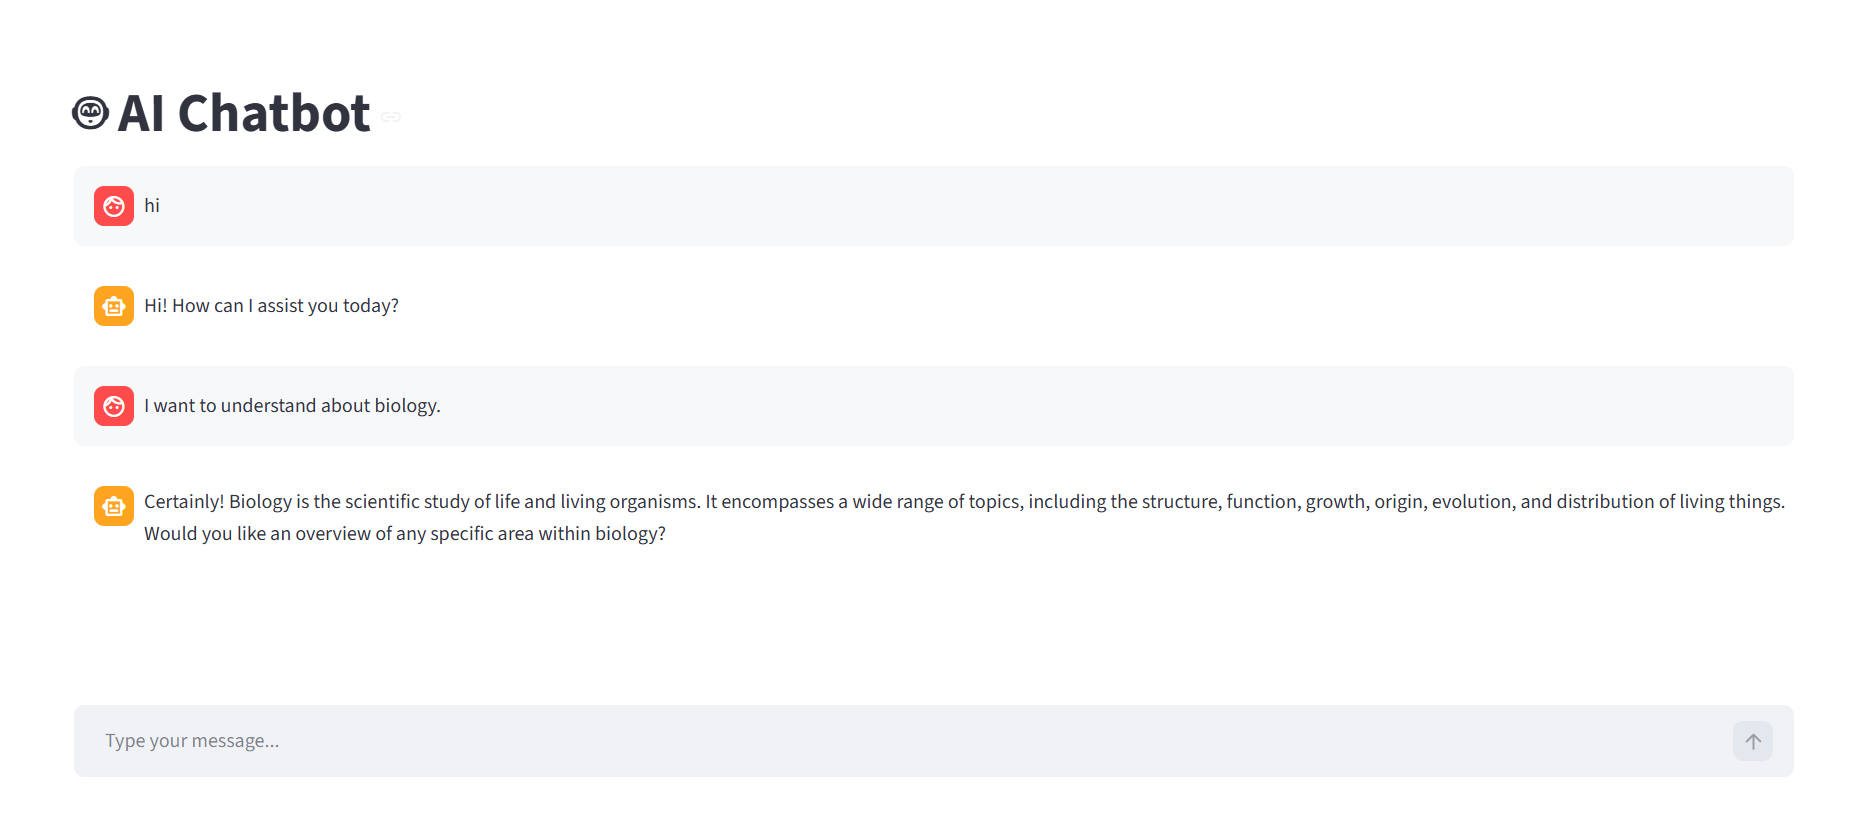

# Construct a Professional, reusable prompt template for International Business Marketing that takes the product name from the user and generates

(1) a global-ready title,

(2) a powerful slogan, and

(3) a product advertising description, written from the perspectives of three distinct Advertising Experts.


Successfully Executed

In [ ]:
product_name = input("Enter product name: ")

prompt = f"""
User:
You are an International Business Marketing AI powered by three world-class Advertising Experts.

Product Name:
"{product_name}"

Task:
For the given product, generate marketing content suitable for global markets.

Expert Perspectives:
1. Global Brand Strategist – focuses on international positioning, brand trust, and scalability.
2. Creative Advertising Director – focuses on emotional appeal, creativity, and memorability.
3. Performance Marketing Expert – focuses on value proposition, benefits, and conversion.

For EACH expert, generate:
A. A compelling global-ready product title
B. One powerful, memorable slogan
C. A concise product advertising description (3–4 lines)

Guidelines:
- Language must be professional, persuasive, and internationally appropriate
- Avoid region-specific slang or cultural references
- Highlight universal benefits
- Maintain a premium global tone

Output Format:
Expert 1: Global Brand Strategist
Title:
Slogan:
Advertising Description:

Expert 2: Creative Advertising Director
Title:
Slogan:
Advertising Description:

Expert 3: Performance Marketing Expert
Title:
Slogan:
Advertising Description:

Assistant:
"""

output = llm(prompt)
print("Assistant:", output[0]["generated_text"])

Enter product name: colgate


NameError: name 'llm' is not defined

In [ ]:
product_name_example = "Quantum Leap Smartwatch"

prompt_template = f"""
User:
You are an International Business Marketing AI powered by three world-class Advertising Experts.

Product Name:
"{product_name_example}"

Task:
For the given product, generate marketing content suitable for global markets.

Expert Perspectives:
1. Global Brand Strategist – focuses on international positioning, brand trust, and scalability.
2. Creative Advertising Director – focuses on emotional appeal, creativity, and memorability.
3. Performance Marketing Expert – focuses on value proposition, benefits, and conversion.

For EACH expert, generate:
A. A compelling global-ready product title
B. One powerful, memorable slogan
C. A concise product advertising description (3–4 lines)

Guidelines:
- Language must be professional, persuasive, and internationally appropriate
- Avoid region-specific slang or cultural references
- Highlight universal benefits
- Maintain a premium global tone

Output Format:
Expert 1: Global Brand Strategist
Title:
Slogan:
Advertising Description:

Expert 2: Creative Advertising Director
Title:
Slogan:
Advertising Description:

Expert 3: Performance Marketing Expert
Title:
Slogan:
Advertising Description:

Assistant:
"""

print(f"Generating marketing content for: {product_name_example}\n")
output = llm(prompt_template)
print(output[0]["generated_text"])

Generating marketing content for: Quantum Leap Smartwatch



NameError: name 'llm' is not defined

#Global Education Content Developer APP - Successfully Executed
successfully Executed

In [ ]:
!pip install streamlit

In [ ]:
%%writefile global_edu_fixed.py
import streamlit as st
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
import torch

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(page_title="🌍 Global Education AI", layout="wide")

st.title("🌍 Global AI Education Content Generator")
st.caption("Agent-Based | Multi-Country | Multi-Language | 2026 Ready")

# -----------------------------
# LOAD MODEL
# -----------------------------
@st.cache_resource
def load_model():
    model_name = "microsoft/Phi-3-mini-4k-instruct"

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="cuda" if torch.cuda.is_available() else "cpu",
        torch_dtype="auto"
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    return pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=600,
        temperature=0.3,
        do_sample=False
    )

llm = load_model()

# -----------------------------
# CLEAN RESPONSE FUNCTION
# -----------------------------
def generate_clean(prompt):
    output = llm(prompt)[0]["generated_text"]

    if "Assistant:" in output:
        return output.split("Assistant:")[-1].strip()
    return output.strip()

# -----------------------------
# SIDEBAR INPUTS
# -----------------------------
st.sidebar.header("🌐 Global Settings")

country = st.sidebar.selectbox(
    "Curriculum",
    ["India (CBSE)", "USA (Common Core)", "UK (GCSE)", "IB (International)"]
)

language = st.sidebar.selectbox(
    "Language",
    ["English", "Tamil", "Hindi", "Spanish", "French"]
)

grade = st.sidebar.selectbox(
    "Level",
    ["School", "UG", "PG"]
)

subject = st.sidebar.text_input("Subject", "Machine Learning")
topic = st.sidebar.text_input("Topic", "Support Vector Machine")

difficulty = st.sidebar.selectbox(
    "Difficulty",
    ["Beginner", "Intermediate", "Advanced"]
)

# -----------------------------
# AGENT DEFINITIONS
# -----------------------------

# 1️⃣ Planner Agent
def planner_agent():
    return f"""
User:
Design a structured lesson plan.

Subject: {subject}
Topic: {topic}
Level: {grade}
Curriculum: {country}
Difficulty: {difficulty}

Output:
- Learning Objectives
- Key Concepts
- Teaching Flow

Assistant:
"""

# 2️⃣ Content Agent
def content_agent(plan):
    return f"""
User:
Based on this lesson plan:

{plan}

Generate:
- Detailed explanation
- Real-world examples
- Visual analogies
- Industry relevance

Assistant:
"""

# 3️⃣ Assessment Agent (FIXED)
def assessment_agent(content):
    return f"""
User:
Based on the following teaching content:

{content}

Generate:
1. 5 MCQs
2. 3 Short Answer Questions
3. 1 Case Study

Assistant:
"""

# 4️⃣ Localization Agent
def localization_agent(text):
    return f"""
User:
Translate and adapt this content into {language}
aligned with {country} curriculum:

{text}

Assistant:
"""

# -----------------------------
# GENERATION PIPELINE
# -----------------------------
if st.button("🚀 Generate Global Content"):

    with st.spinner("AI Agents Collaborating..."):

        # Step 1: Planner
        plan = generate_clean(planner_agent())

        # Step 2: Content
        content = generate_clean(content_agent(plan))

        # Step 3: Assessment
        assessment = generate_clean(assessment_agent(content))

        # Step 4: Localization
        final_output = generate_clean(
            localization_agent(plan + "\n\n" + content + "\n\n" + assessment)
        )

    st.success("✅ Content Generated Successfully")

    # -----------------------------
    # OUTPUT TABS
    # -----------------------------
    tab1, tab2, tab3, tab4 = st.tabs(
        ["📘 Lesson Plan", "📚 Content", "📝 Assessment", "🌐 Localized"]
    )

    with tab1:
        st.markdown("### 📘 Lesson Plan")
        st.write(plan)

    with tab2:
        st.markdown("### 📚 Teaching Content")
        st.write(content)

    with tab3:
        st.markdown("### 📝 Assessment")
        st.write(assessment)

    with tab4:
        st.markdown("### 🌐 Localized Output")
        st.write(final_output)

# -----------------------------
# FOOTER
# -----------------------------
st.markdown("---")
st.caption("🚀 Global AI Education Platform | Agent-Based System | 2026")

Writing global_edu_fixed.py


In [ ]:
!pip install streamlit -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

!pkill streamlit || echo "No previous Streamlit process"
import time, subprocess

streamlit_proc = subprocess.Popen(["streamlit", "run", "global_edu_fixed.py", "--server.port", "8501", "--server.headless", "true"])
time.sleep(8)

# Create tunnel
!cloudflared tunnel --url http://localhost:8501 --no-autoupdate

Selecting previously unselected package cloudflared.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...
No previous Streamlit process
2026-03-26T09:44:02Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-26T09:44:02Z INF Requesting new quick Tunnel on trycloudflare

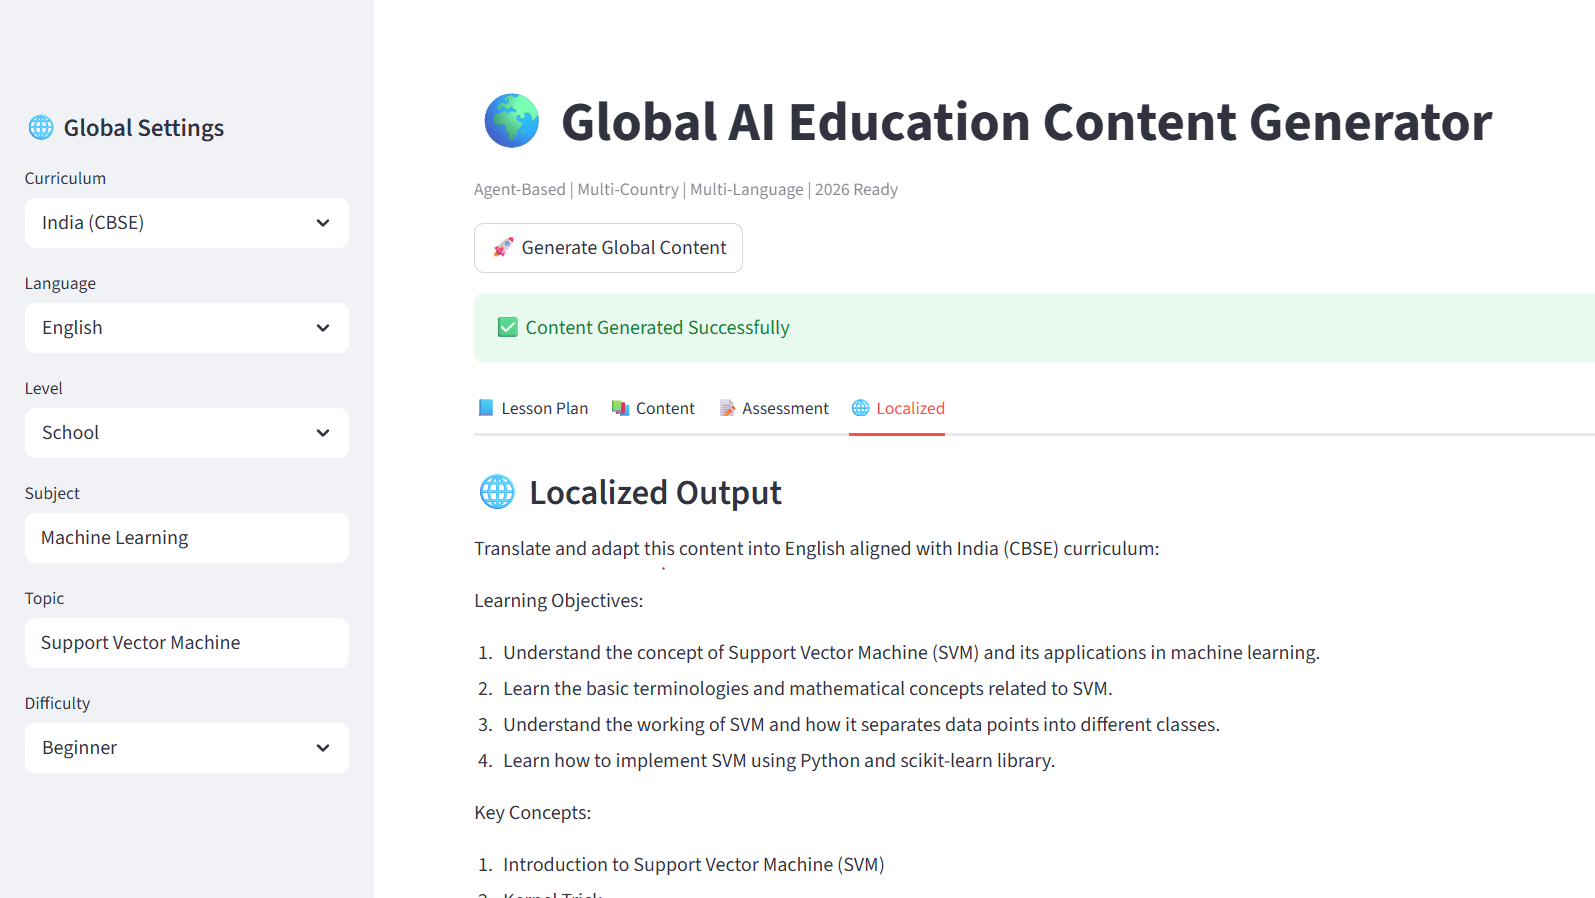

#IMAGE GENERATION USING STABLE DIFFUSION
successfully Executed

In [ ]:
%%capture
!pip install diffusers transformers accelerate safetensors scipy streamlit torch --upgrade

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "dreamlike-art/dreamlike-diffusion-1.0"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

In [ ]:
prompt = "dreamlikeart, a grungy woman with rainbow hair, travelling between dimensions, dynamic pose, happy, soft eyes and narrow chin, extreme bokeh, dainty figure, long hair straight down, torn kawaii shirt and baggy jeans, In style of by Jordan Grimmer and greg rutkowski, crisp lines and color, complex background, particles, lines, wind, concept art, sharp focus, vivid colors"
image = pipe(prompt).images[0]

image.save("./result.jpg")

In [ ]:
import matplotlib.pyplot as plt

prompt2 = 'Natural scenary with waterfall, puppy playing in waterfall'

image = pipe(prompt2).images[0]
print("[PROMPT]: ",prompt2)
plt.imshow(image);
plt.axis('off');

In [ ]:
%%writefile app.py
import streamlit as st
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------
# Streamlit UI
# ---------------------
st.title("Stable Diffusion Image Generator (Colab)")
st.write("Generate AI art using Dreamlike Diffusion model.")

# Default prompt
prompt = st.text_input("Enter your prompt:", "Mom loves kids and flowers")

generate = st.button("Generate Image")

if generate:
    st.write("Loading model... (only first time)")

    model_id = "dreamlike-art/dreamlike-diffusion-1.0"

    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        use_safetensors=True
    )

    pipe = pipe.to("cuda")

    st.write(f"**[PROMPT]**: {prompt}")

    # Generate image
    with torch.autocast("cuda"):
        image = pipe(prompt).images[0]

    st.image(image, caption="Generated Image", use_column_width=True)


A serene misty forest at dawn with a crystal-clear river winding through ancient trees, deer grazing peacefully by the water's edge, vibrant wildflowers dotting the lush green undergrowth, soft golden sunlight filtering through the canopy, photorealistic wildlife scene in high detail.

In [ ]:
%%writefile app.py
import streamlit as st
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------
# Streamlit UI
# ---------------------
st.title("Stable Diffusion Image Generator (Colab)")
st.write("Generate AI art using Dreamlike Diffusion model.")

# Default prompt
prompt = st.text_input("Enter your prompt:", "Mom loves kids and flowers")

generate = st.button("Generate Image")

if generate:
    st.write("Loading model... (only first time)")

    model_id = "dreamlike-art/dreamlike-diffusion-1.0"

    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        use_safetensors=True
    )

    pipe = pipe.to("cuda")

    st.write(f"**[PROMPT]**: {prompt}")

    # Generate image
    with torch.autocast("cuda"):
        image = pipe(prompt).images[0]

    st.image(image, caption="Generated Image", use_column_width=True)


In [ ]:
!pip install streamlit -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

!pkill streamlit || echo "No previous Streamlit process"
import time, subprocess

streamlit_proc = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"])
time.sleep(8)

# Create tunnel
!cloudflared tunnel --url http://localhost:8501 --no-autoupdate

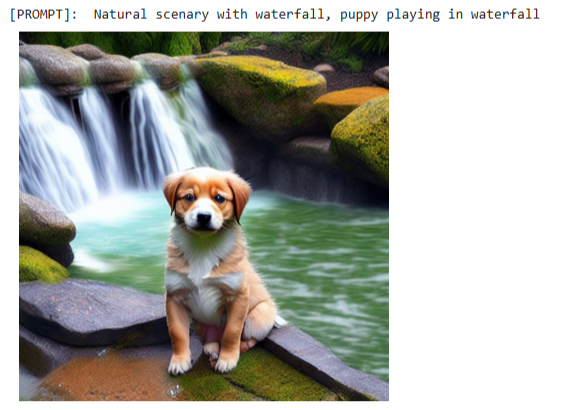

#Pandas AI Analytics Agent
successfully Executed

Step 1: Create Groq API Key

https://console.groq.com/keys



In [ ]:
%%capture
!pip install langchain_experimental langchain-groq langchain-experimental

!pip install langchain langchain-openai pandas==2.1.4


In [ ]:
%%writefile pandas_EDA_app.py
import streamlit as st
import pandas as pd
import os

from langchain_groq.chat_models import ChatGroq
from langchain_experimental.agents.agent_toolkits.pandas.base import create_pandas_dataframe_agent
from langchain_experimental.agents import create_pandas_dataframe_agent

# -----------------------------
# Page Config
# -----------------------------
st.set_page_config(page_title="🌍 DataInsight AI Agent", layout="wide")

st.title("🌍 DataInsight AI Agent")
st.subheader("Ask questions from your dataset using AI")

# -----------------------------
# Secure API Key Input
# -----------------------------
groq_api_key = st.text_input("Enter Groq API Key", type="password")

# -----------------------------
# File Upload
# -----------------------------
uploaded_file = st.file_uploader("Upload Excel File", type=["xlsx"])

if uploaded_file and groq_api_key:

    # Load Data
    df = pd.read_excel(uploaded_file)

    st.write("### 📊 Dataset Preview")
    st.dataframe(df.head())

    # Initialize LLM
    llm = ChatGroq(
        model_name="llama-3.1-8b-instant",
        api_key=groq_api_key
    )

    # Create Agent
    agent = create_pandas_dataframe_agent(
        llm,
        df,
        verbose=True,
        allow_dangerous_code=True
    )

    # -----------------------------
    # User Query
    # -----------------------------
    user_query = st.text_input("Ask your question:")

    if user_query:
        with st.spinner("Analyzing..."):
            try:
                response = agent.run(user_query)
                st.success("✅ Answer:")
                st.write(response)
            except Exception as e:
                st.error(f"Error: {e}")

else:
    st.info("Please upload a dataset and enter API key to proceed.")

In [ ]:
!pip install streamlit -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

!pkill streamlit || echo "No previous Streamlit process"
import time, subprocess

streamlit_proc = subprocess.Popen(["streamlit", "run", "pandas_EDA_app.py", "--server.port", "8501", "--server.headless", "true"])
time.sleep(8)

# Create tunnel
!cloudflared tunnel --url http://localhost:8501 --no-autoupdate

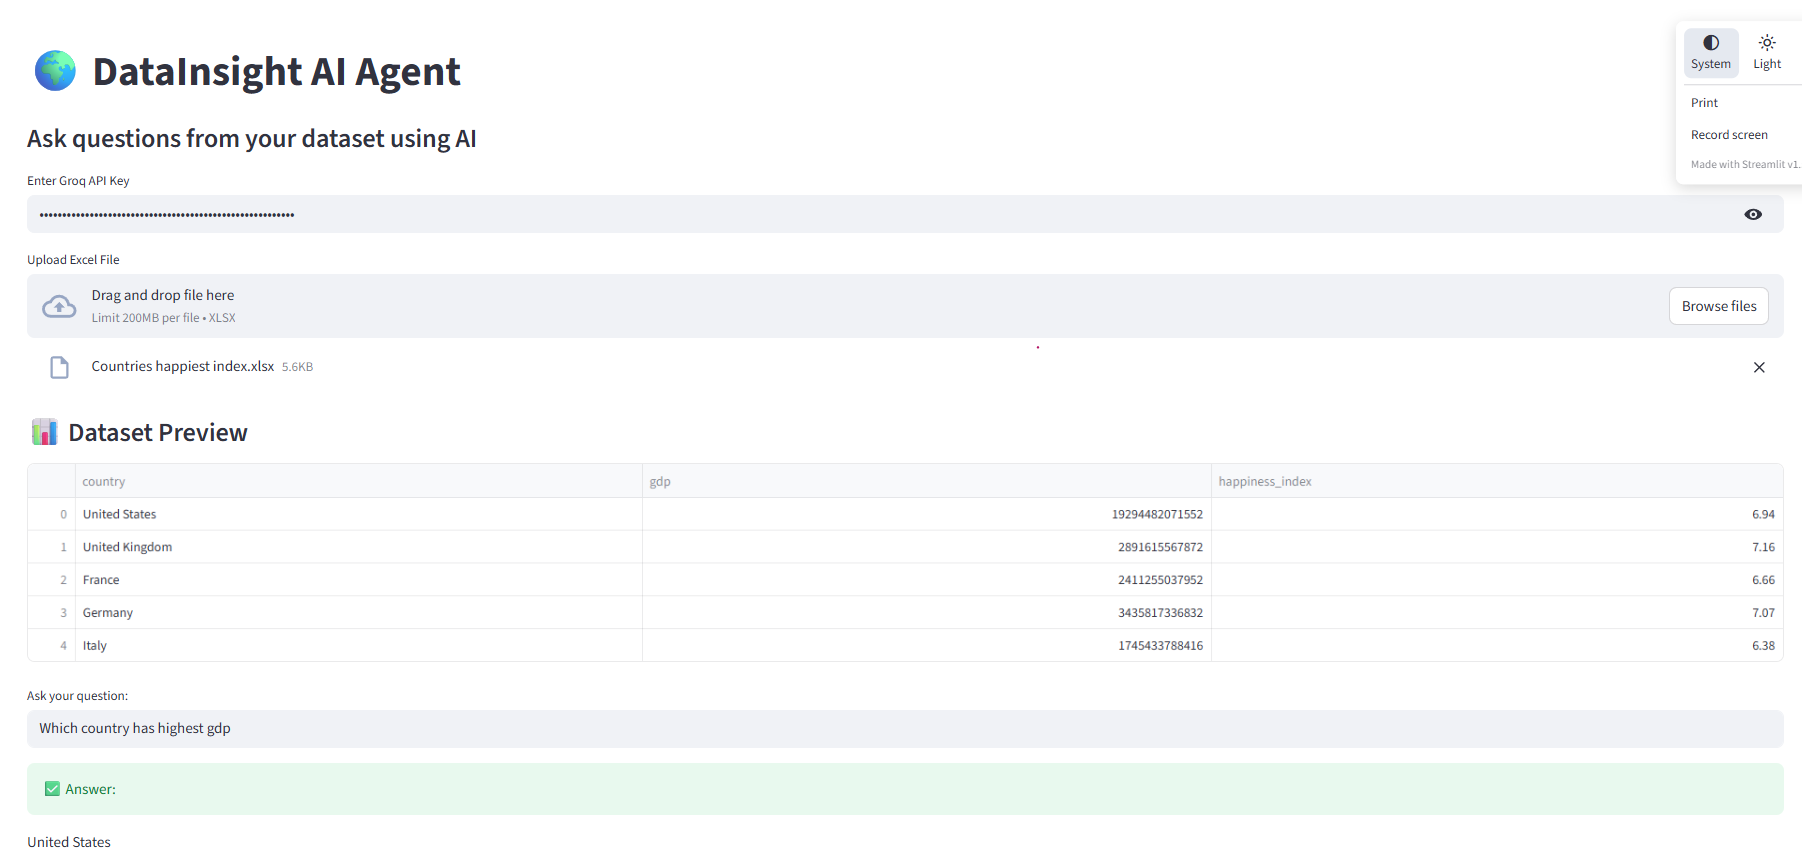

In [ ]:
import pandas as pd
df=pd.read_excel("/content/Countries happiest index.xlsx")

In [ ]:
agent = create_pandas_dataframe_agent(
    llm,
    df,
    verbose=True,
    allow_dangerous_code=True
)

In [ ]:
!pip install openpyxl

In [ ]:
llm = ChatGroq(model_name="llama-3.1-8b-instant", api_key = "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")


In [ ]:
agent.run("Who is the Happiest Country?")


To be continued....